# Question 1: Plotting Signals



In [4]:
# makin a plot_time function for the signal in time domain

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_time(x, fs):
    
    t_x = np.linspace(0, len(x) / fs, num=len(x), endpoint=False)
    
    plt.figure(figsize=(10, 4))
    plt.plot(t_x, x)
    plt.title("Time Domain Signal")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()


fs = 50  # sampling frequency 
duration = 5  # Duration length of the signal in seconds
t_x = np.linspace(0, duration, int(fs * duration), endpoint=False)  
x = np.sin(2 * np.pi * 5 * t_x)  # 5 Hz sine wave



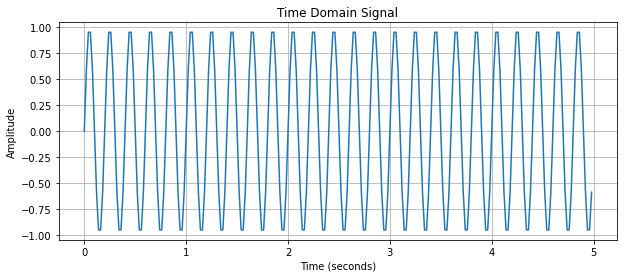

In [3]:
plot_time(x, fs)

## Question 1b

In [5]:
# Plotting Frequencies for this i have to create the plot_freq function

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def plot_freq(X, fs):
    n = len(X)
    
    freq = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    # shifting the array 
    X_shifted = np.fft.fftshift(X)
    amplitude = np.abs(X_shifted)
    phase = np.angle(X_shifted)
    
    threshold=1e-5
    phase[amplitude < threshold] = 0
    # creating object for the subplots like fig object and the axes objects
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(freq, amplitude)
    # title of the graph
    ax1.set_title("Amplitude Spectrum")
    # x labels of the graph
    ax1.set_xlabel("Frequency (Hz)")
    # y labels of the graph
    ax1.set_ylabel("Amplitude")
    ax1.grid(True)
    
    ax2.plot(freq, phase)
    ax2.set_title("Phase Spectrum")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Phase (radians)")
    ax2.grid(True)
    plt.show()

fs = 50  # Sampling frequency

t = np.linspace(0, 5, int(5 * fs), endpoint=False)  # Time vector
x = np.sin(2 * np.pi * 5 * t)  # Sine wave

# the DFT of the signal
X = np.fft.fft(x)


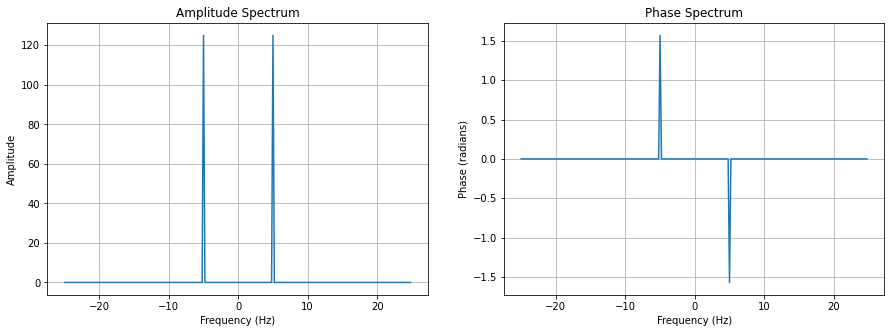

In [7]:
plot_freq(X, fs)

## Question 2


In [15]:
import numpy as np

def psd(x, w, fs):

    N = len(x)
    x_w = x * w
    X = np.fft.fft(x_w)
    S = np.sum(w ** 2)  # Sum of the squared window values
    freqs = np.fft.fftfreq(N, d=1/fs)
    pos_freqs = freqs[freqs >= 0]
    psd_vals = 2 * (np.abs(X[freqs >= 0]) ** 2) / (fs * S)
    
    return pos_freqs, psd_vals


For verifying the **orthognality** i have compute the dot products of each tapers

- if the dot product valus is 0 or close to zero it means they are orthognal.
- The matrix below shows the dot product results 
- the diagonal values are the utself dot product that is why it is 1

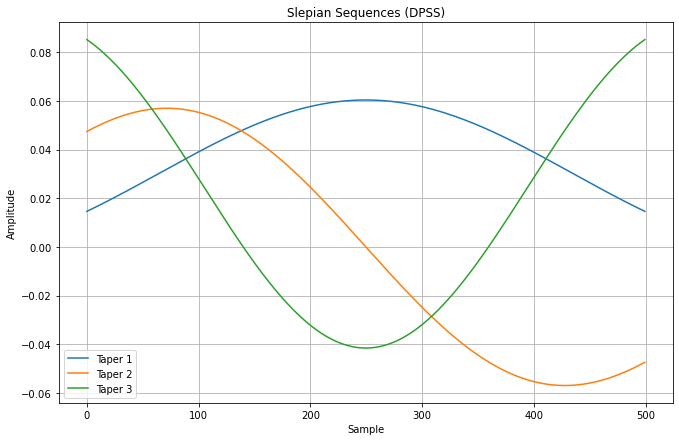

Orthogonality matrix:
 [[ 1.00000000e+00 -7.69783542e-18 -9.75781955e-19]
 [-7.69783542e-18  1.00000000e+00 -2.08166817e-17]
 [-9.75781955e-19 -2.08166817e-17  1.00000000e+00]]


In [16]:
import matplotlib.pyplot as plt
from scipy.signal.windows import dpss

M = 500  # Length of the taper
NW = 1  # Time-bandwidth parameter
tapers = dpss(M, NW, Kmax=3)


plt.figure(figsize=(11, 7))
for i, taper in enumerate(tapers):
    plt.plot(taper, label=f"Taper {i+1}")
plt.legend()
plt.title("Slepian Sequences (DPSS)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Verify orthogonality
orthogonality = np.array([[np.dot(t1, t2) for t2 in tapers] for t1 in tapers])
print("Orthogonality matrix:\n", orthogonality)


In [17]:
from scipy.signal.windows import dpss
def multitaper(x, fs, k):

    N = len(x)
    NW = N / fs 
    tapers = dpss(N, NW, Kmax=k)
    
    psd_list = []
    for taper in tapers:
        f, psd_vals = psd(x, taper, fs)
        psd_list.append(psd_vals)
    
    multitaper_psd = np.mean(psd_list, axis=0)  
    return f, multitaper_psd


Sampling frequency: 22050 Hz


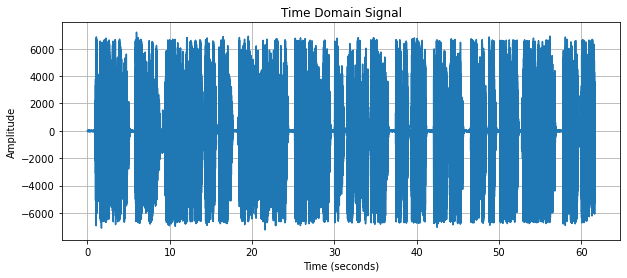

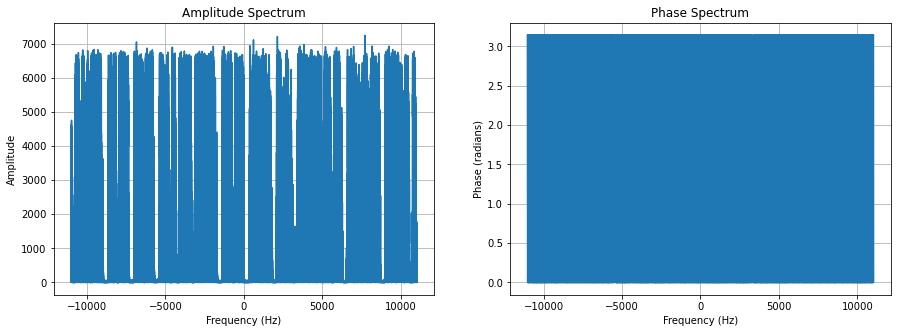

In [18]:
import scipy.io.wavfile as wavfile
import numpy as np
import matplotlib.pyplot as plt

fs, signal = wavfile.read('speech.wav')
print(f"Sampling frequency: {fs} Hz")

if len(signal.shape) == 2:
    signal = signal.mean(axis=1)

# Plot the signal in the time domain
plot_time(signal, fs)

# Plot the signal in the frequency domain
plot_freq(signal, fs)



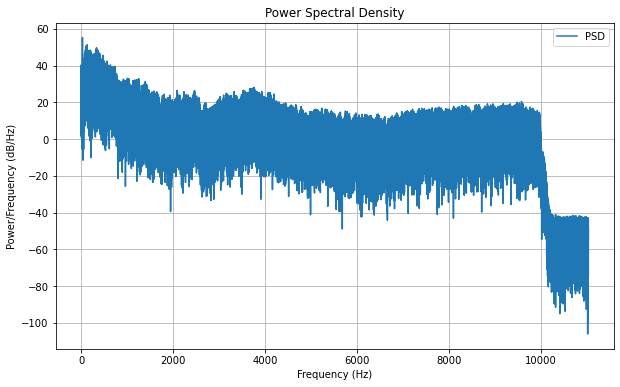

In [19]:
# Compute and plot the PSD
N = len(signal)
window = np.hanning(N)  # Use Hanning window
frequencies, psd_values = psd(signal, window, fs)

plt.figure(figsize=(10, 6))
plt.plot(frequencies, 10 * np.log10(psd_values), label="PSD")
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid()
plt.legend()
plt.show()

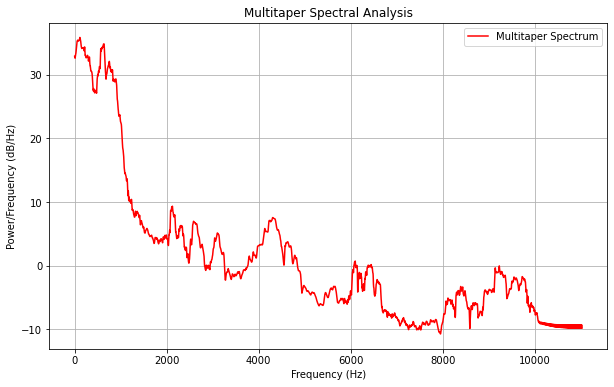

In [20]:

# Compute and plot the multitaper spectrum using 20 tapers
frequencies, multitaper_values = multitaper(signal, fs, k=20)

plt.figure(figsize=(10, 6))
plt.plot(frequencies, 10 * np.log10(multitaper_values), label="Multitaper Spectrum", color='r')
plt.title("Multitaper Spectral Analysis")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid()
plt.legend()
plt.show()


# Question 3

In [21]:
import numpy as np
from scipy.signal.windows import hann
# function for the short time fourier transform
def stft(x, fs, wlen, win_func=False):

    N = len(x)
    # Samples per window
    window_length = int(fs * wlen)  
    # Number of windows
    n_windows = N // window_length 
    # Frequency and time arrays
    freqs = np.fft.fftfreq(window_length, d=1/fs)[:window_length//2 + 1]
    times = np.arange(0, n_windows) * wlen
    
    # Hann window function
    if win_func:
        window = hann(window_length)
    else:
        window = np.ones(window_length)

    stft_matrix = []
    
    for i in range(n_windows):
        segment = x[i * window_length : (i + 1) * window_length]
        # Ensure all segments are same length
        if len(segment) < window_length:  
            break
        # Apply window function
        segment = segment * window  
        # Positive frequencies only
        spectrum = np.fft.fft(segment)[:window_length//2 + 1]  
        stft_matrix.append(spectrum)
    # Transpose for correct shape
    stft_matrix = np.array(stft_matrix).T  
    return stft_matrix, freqs, times


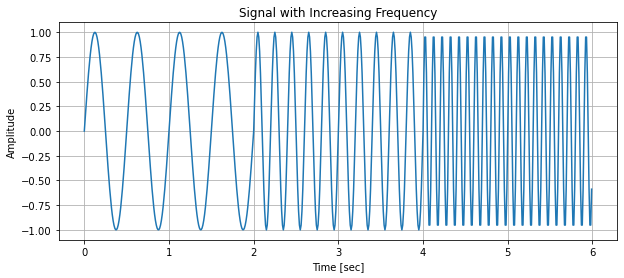

In [23]:
import matplotlib.pyplot as plt
# recreating the signal given in the assignment
# Define the signal
fs = 100  # Sampling frequency
t = np.arange(0, 6, 1/fs)  # Time vector from 0 to 6 seconds
signal = np.piecewise(t, 
                      [t < 2, (t >= 2) & (t < 4), t >= 4],
                      [lambda t: np.sin(2 * np.pi * 2 * t),  # 2 Hz
                       lambda t: np.sin(2 * np.pi * 5 * t),  # 5 Hz
                       lambda t: np.sin(2 * np.pi * 10 * t)])  # 10 Hz

# Plot the signal in the time domain
plt.figure(figsize=(10, 4))
plt.plot(t, signal)
plt.title("Signal with Increasing Frequency")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


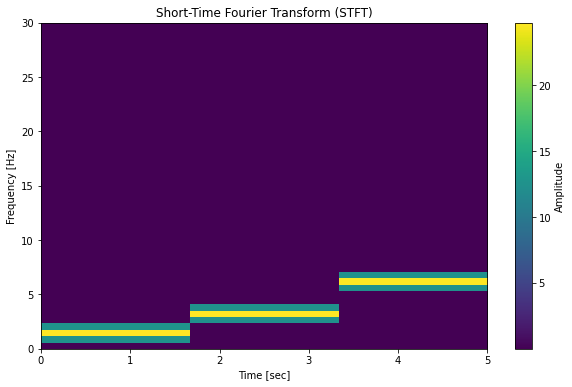

In [26]:
def plot_colormap_stft(stft_matrix, fs, times, freqs, fmax=None, log=False, colormap_min=None, colormap_max=None):

    magnitude = np.abs(stft_matrix)
    if log:
        magnitude = np.log(magnitude + 1e-10)  # Avoid log(0)
    
    plt.figure(figsize=(10, 6))
    extent = [times[0], times[-1], freqs[0], fmax or freqs[-1]]
    plt.imshow(magnitude, aspect='auto', origin='lower', extent=extent, vmin=colormap_min, vmax=colormap_max)
    plt.colorbar(label="Amplitude")
    plt.title("Short-Time Fourier Transform (STFT)")
    plt.xlabel("Time [sec]")
    plt.ylabel("Frequency [Hz]")
    plt.show()

# Compute the STFT
wlen = 1.0  # Window length in seconds
stft_matrix, freqs, times = stft(signal, fs, wlen, win_func=True)

# Plot the STFT
plot_colormap_stft(stft_matrix, fs, times, freqs, fmax=30)


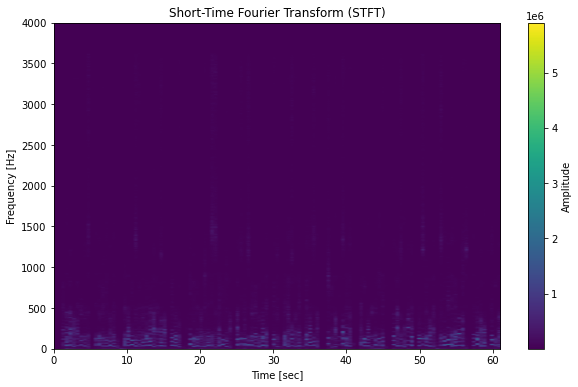

In [27]:
from scipy.io.wavfile import read

# Load the audio file
fs, speech_signal = read('speech.wav')

# Convert to mono if stereo
if len(speech_signal.shape) == 2:
    speech_signal = speech_signal.mean(axis=1)

# Compute the STFT
wlen = 0.5  # Window length in seconds
stft_matrix, freqs, times = stft(speech_signal, fs, wlen, win_func=True)

# Plot the STFT with suitable fmax
plot_colormap_stft(stft_matrix, fs, times, freqs, fmax=4000)


# Question 4

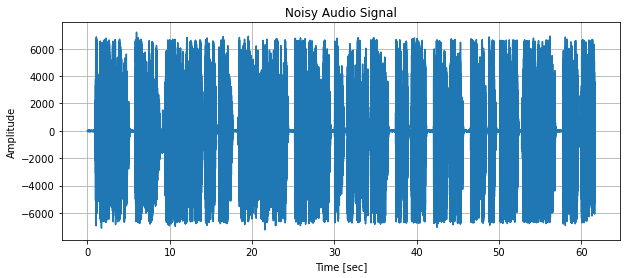

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io.wavfile import read

# Load the noisy audio file
fs, noisy_signal = read("noisy.wav")

# Convert to mono if stereo
if len(noisy_signal.shape) == 2:
    noisy_signal = noisy_signal.mean(axis=1)

# Play the noisy audio
sd.play(noisy_signal, fs)

# Time vector
t = np.linspace(0, len(noisy_signal) / fs, len(noisy_signal))

# Plot the noisy signal in the time domain
plt.figure(figsize=(10, 4))
plt.plot(t, noisy_signal)
plt.title("Noisy Audio Signal")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


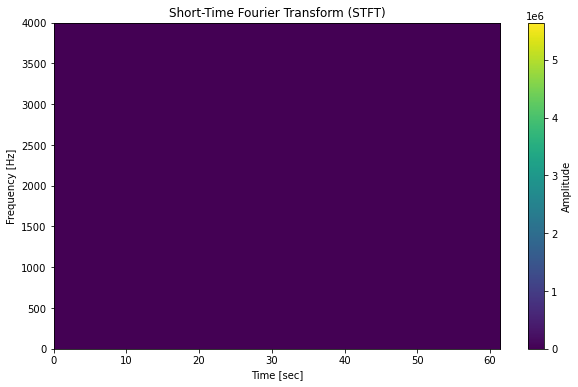

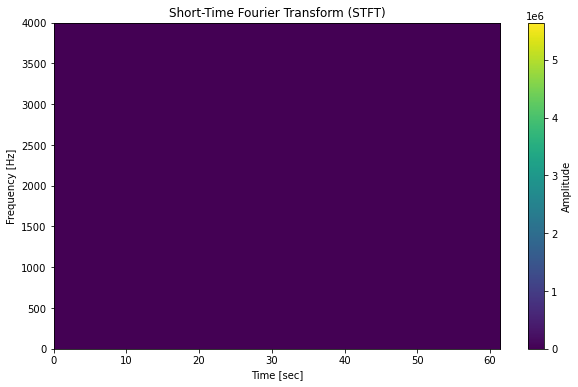

Frequency resolution: 5.0 Hz


In [32]:
# Import the previously defined STFT and plotting function
from scipy.signal.windows import hann

# Parameters
wlen = 0.2  # Window length in seconds
window_length = int(fs * wlen)

# STFT with rectangular window
stft_rect, freqs, times = stft(noisy_signal, fs, wlen, win_func=False)

# STFT with Hann window
stft_hann, freqs, times = stft(noisy_signal, fs, wlen, win_func=True)

# Maximum amplitude for consistent color scale
max_amplitude = max(np.abs(stft_rect).max(), np.abs(stft_hann).max())

# Plot STFT with rectangular window
plot_colormap_stft(stft_rect, fs, times, freqs, fmax=4000, log=True, colormap_min=0, colormap_max=max_amplitude)

# Plot STFT with Hann window
plot_colormap_stft(stft_hann, fs, times, freqs, fmax=4000, log=True, colormap_min=0, colormap_max=max_amplitude)

# Frequency resolution
frequency_resolution = fs / window_length
print(f"Frequency resolution: {frequency_resolution} Hz")


In [38]:
def noise_gate(W, t_noise, c_thresh):

    # Identify noise epoch
    noise_idx = int(t_noise / wlen)
    noise_matrix = W[:, :noise_idx]
    # Calculate log-scaled mean of the per frequency
    log_amplitude = np.log(np.abs(noise_matrix) + 1e-10)
    mu = np.mean(log_amplitude, axis=1)  
    # calculare std per frequency
    sigma = np.std(log_amplitude, axis=1)  
    
    # Threshold calculation
    thresh = mu[:, np.newaxis] + c_thresh * sigma[:, np.newaxis]
    
    # Apply noise gate
    log_W = np.log(np.abs(W) + 1e-10)
    W_clean = np.where(log_W >= thresh, W, 0)
    
    return W_clean

# Apply noise gate with c_thresh=3
W_clean_est = noise_gate(stft_rect, t_noise=5, c_thresh=3)
W_clean_hann = noise_gate(stft_hann, t_noise=5, c_thresh=3)


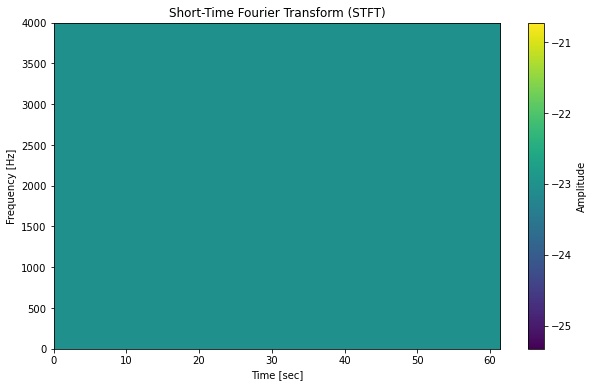

In [39]:
plot_colormap_stft(W_clean_est, fs, times, freqs, fmax=4000, log=True)


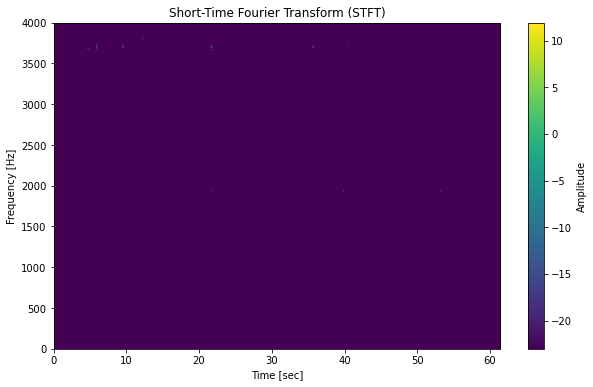

In [40]:
plot_colormap_stft(W_clean_hann, fs, times, freqs, fmax=4000, log=True)

<ipython-input-41-3257b80735d5>:21: RuntimeWarning: invalid value encountered in true_divide
  z_clean_rect = np.int16(z_clean_rect / np.max(np.abs(z_clean_rect)) * 32767)


Playing cleaned audio (Rectangular Window):
Playing cleaned audio (Hann Window):


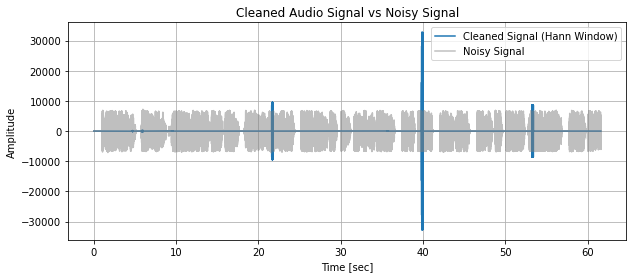

In [41]:
from scipy.io.wavfile import write

def istft(X_stft):

    n_windows, n_freqs = X_stft.shape[1], X_stft.shape[0]
    window_length = (n_freqs - 1) * 2
    signal_length = n_windows * window_length
    x_reconstructed = np.zeros(signal_length)

    for i in range(n_windows):
        segment = np.fft.ifft(np.concatenate([X_stft[:, i], np.conj(X_stft[-2:0:-1, i])])).real
        x_reconstructed[i * window_length: (i + 1) * window_length] += segment

    return x_reconstructed

# Reconstruct signals
z_clean_rect = istft(W_clean_rect)
z_clean_hann = istft(W_clean_hann)

# Scale signals
z_clean_rect = np.int16(z_clean_rect / np.max(np.abs(z_clean_rect)) * 32767)
z_clean_hann = np.int16(z_clean_hann / np.max(np.abs(z_clean_hann)) * 32767)

# Save cleaned audio
write("cleaned_rect.wav", fs, z_clean_rect)
write("cleaned_hann.wav", fs, z_clean_hann)

# Play the cleaned audio
print("Playing cleaned audio (Rectangular Window):")
sd.play(z_clean_rect, fs)
sd.wait()

print("Playing cleaned audio (Hann Window):")
sd.play(z_clean_hann, fs)
sd.wait()

# Recompute the time vector based on the cleaned signal length
t_clean = np.linspace(0, len(z_clean_hann) / fs, len(z_clean_hann))

# Plot cleaned audio signal vs noisy signal
plt.figure(figsize=(10, 4))
plt.plot(t_clean, z_clean_hann, label="Cleaned Signal (Hann Window)")
plt.plot(t[:len(noisy_signal)], noisy_signal[:len(t)], alpha=0.5, label="Noisy Signal", color='gray')
plt.title("Cleaned Audio Signal vs Noisy Signal")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

## Question 5

In [43]:
import numpy as np
from numpy.fft import fft, ifft, fftshift
import matplotlib.pyplot as plt

def ideal_lowpass(fc, fs, M):

    # Frequency resolution
    freq_res = fs / M
    f = np.linspace(-fs / 2, fs / 2, M)
    
    # Define amplitude spectrum
    H_0 = np.where(np.abs(f) <= fc, 1, 0)
    
    # Compute impulse response using inverse FFT
    h_0 = fftshift(np.real(ifft(fftshift(H_0))))
    
    return H_0, h_0

In [45]:
def hann_window(M):
    n = np.arange(M)
    w = 0.5 - 0.5 * np.cos(2 * np.pi * n / (M - 1))
    return w


In [47]:
def fir_lowpass(fc, fs, M):

    # Design ideal low-pass filter
    H0, h0 = ideal_lowpass(fc, fs, M)
    
    # Generate Hann window
    w_hann = hann_window(M)
    
    # Multiply ideal impulse response with window
    h_fir = h0 * w_hann
    
    # Compute amplitude spectrum
    H_fir = fftshift(np.abs(fft(h_fir)))
    
    return H_fir, h_fir


Comments on the Graphs

- The tails of the Impulse response using the hann window gets zero, means it becomes flat
- and in the time domain as you can see there is no flat line we have highs and lows curves

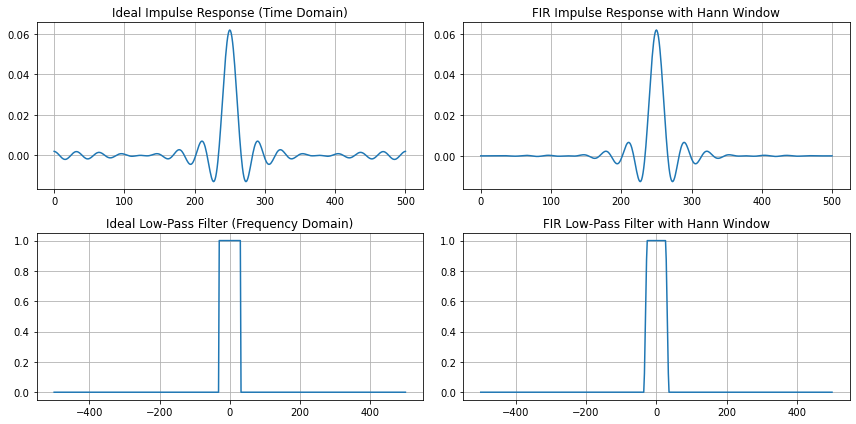

In [49]:
# Parameters as per question
M = 501  # Filter length
fc = 30  # Cut-off frequency
fs = 1000  # Sampling frequency

# Design filters
H_0, h_0 = ideal_lowpass(fc, fs, M)
H_fir, h_fir = fir_lowpass(fc, fs, M)

# Plot impulse responses
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(h_0, label="Ideal Impulse Response")
plt.title("Ideal Impulse Response (Time Domain)")
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(h_fir, label="FIR Impulse Response")
plt.title("FIR Impulse Response with Hann Window")
plt.grid()

# Plot amplitude spectra
frequencies = np.linspace(-fs/2, fs/2, M)
plt.subplot(2, 2, 3)
plt.plot(frequencies, H_0, label="Ideal Filter")
plt.title("Ideal Low-Pass Filter (Frequency Domain)")
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(frequencies, H_fir, label="FIR Filter")
plt.title("FIR Low-Pass Filter with Hann Window")
plt.grid()
plt.tight_layout()
plt.show()


## Question 5b 

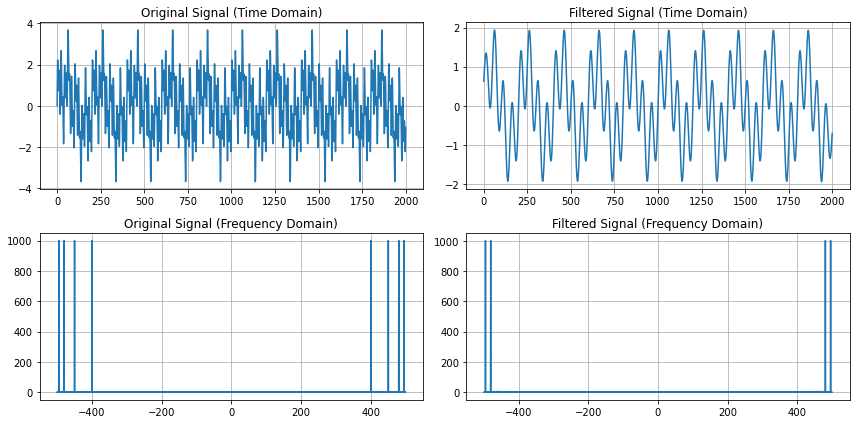

In [50]:
# Define multi-frequency signal
fs = 1000  # Sampling frequency
N = 2000  # Signal length
n = np.arange(N)
x = (np.sin(2 * np.pi * 5 * n / fs) + 
     np.sin(2 * np.pi * 20 * n / fs) +
     np.sin(2 * np.pi * 50 * n / fs) +
     np.sin(2 * np.pi * 100 * n / fs))

# Apply FIR filter using convolution
h_fir = fir_lowpass(fc=30, fs=fs, M=501)[1]
x_filt = np.convolve(x, h_fir, mode='same')

# Plot time and frequency domains
frequencies = np.fft.fftfreq(N, 1/fs)
X = np.fft.fft(x)
X_filt = np.fft.fft(x_filt)

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(n, x)
plt.title("Original Signal (Time Domain)")
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(n, x_filt)
plt.title("Filtered Signal (Time Domain)")
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(frequencies, np.abs(np.fft.fftshift(X)))
plt.title("Original Signal (Frequency Domain)")
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(frequencies, np.abs(np.fft.fftshift(X_filt)))
plt.title("Filtered Signal (Frequency Domain)")
plt.grid()
plt.tight_layout()
plt.show()


In [51]:
from scipy.io.wavfile import read, write

# Load Beethoven audio file
fs, audio = read("beethoven.wav")

# Convert to mono
if len(audio.shape) == 2:
    audio = audio.mean(axis=1)

# Define downsampling factors
c_down_factors = [5, 10, 20]

for c_down in c_down_factors:
    # Naive downsampling
    audio_down_naive = audio[::c_down]
    fs_down = fs // c_down
    
    # Proper downsampling
    fc = fs / (2 * c_down)
    h_fir = fir_lowpass(fc, fs, 501)[1]
    audio_filtered = np.convolve(audio, h_fir, mode='same')
    audio_down_proper = audio_filtered[::c_down]
    
    # Save audio
    write(f"audio_down_naive_{c_down}.wav", fs_down, np.int16(audio_down_naive))
    write(f"audio_down_proper_{c_down}.wav", fs_down, np.int16(audio_down_proper))
    
    # Print results
    print(f"Factor: {c_down}, Sampling Rate: {fs_down} Hz, Length: {len(audio_down_proper)} samples")


Factor: 5, Sampling Rate: 4410 Hz, Length: 271767 samples
Factor: 10, Sampling Rate: 2205 Hz, Length: 135884 samples
Factor: 20, Sampling Rate: 1102 Hz, Length: 67942 samples


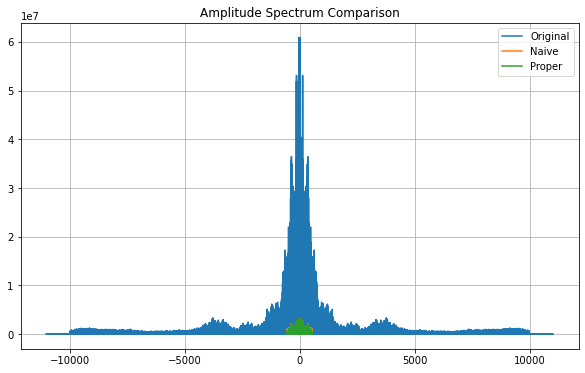

In [55]:
# Plot spectra for original, naive, and proper downsampling
plt.figure(figsize=(10, 6))
plt.plot(np.fft.fftfreq(len(audio), 1/fs), np.abs(np.fft.fft(audio)), label="Original")
plt.plot(np.fft.fftfreq(len(audio_down_naive), 1/fs_down), np.abs(np.fft.fft(audio_down_naive)), label="Naive")
plt.plot(np.fft.fftfreq(len(audio_down_proper), 1/fs_down), np.abs(np.fft.fft(audio_down_proper)), label="Proper")
plt.legend()
plt.title("Amplitude Spectrum Comparison")
plt.grid()
plt.show()


## 5 c


In [53]:
# sounddevice playa ()

SyntaxError: invalid syntax (<ipython-input-53-c7c36224f8c8>, line 1)

In [54]:
#Does your filter work properly? Discuss your results!